In [76]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from datetime import datetime as dt
import sys
sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')

from read_datasets import read_dataset

In [60]:
dir_path = Path('/scratch/er8/cd3022/weather-features/jet/')
files = [f for f in dir_path.glob('*202001*jetaxis.nc')]
ds = xr.open_mfdataset(files).compute()

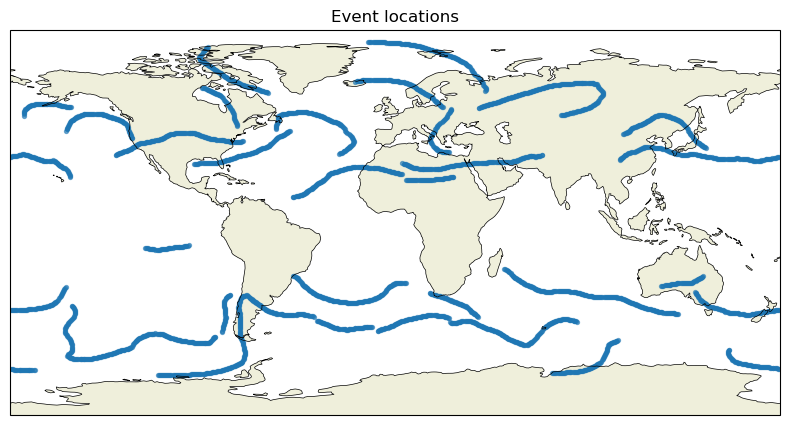

In [133]:
date = np.datetime64('2020-01-05T21')

data = ds.where(ds.date == date, drop=True)
# data.where(ds1.line_id == 1, drop=True)

lats = data["latitude"].values   # or ds["lat"]
lons = data["longitude"].values  # or ds["lon"]

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()

ax.scatter(
    lons, lats,
    s=8, alpha=0.6,
    transform=ccrs.PlateCarree()
)

ax.set_title("Event locations")
plt.show()

In [111]:
bar = read_dataset(
    dataset='barra-r2',
    resolution='hourly',
    date='2020-01'
)
bar = bar.assign_coords(time=bar.time - pd.Timedelta('30min'))

In [130]:
lat_max = ds.latitude < bar.lat.max().item()
lat_min = ds.latitude > bar.lat.min().item()
lon_max = ds.longitude < bar.lon.max().item()
lon_min = ds.longitude > bar.lon.min().item()

ds_reg = ds.where(lat_max & lat_min & lon_max & lon_min, drop=True)

In [115]:
mask = xr.DataArray(
    np.zeros((bar.sizes["time"], bar.sizes["lat"], bar.sizes["lon"]), dtype=bool),
    coords={"time": bar.time, "lat": bar.lat, "lon": bar.lon},
    dims=("time", "lat", "lon"),
    name="jetaxes_mask",
)

In [144]:
bar.time.values[it].astype(str)

'2020-01-01T00:00:00.000000000'

In [147]:
box

<xarray.DataArray (lat: 314, lon: 403)> Size: 127kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lat      (lat) float64 3kB -44.44 -44.33 -44.22 ... -10.23 -10.12 -10.01
  * lon      (lon) float64 3kB 112.0 112.1 112.2 112.3 ... 156.0 156.1 156.2
    crs      int32 4B 0

In [ ]:
deg = 0.5
tolerance = np.timedelta64(1, "h")

# bool mask with same shape as ghi
mask = xr.zeros_like(bar["ghi"], dtype=bool)

for t, lat, lon in zip(ds_reg.date.values, ds_reg.latitude.values, ds_reg.longitude.values):
    it = np.argmin(np.abs(bar.time.values - t))
    if np.abs(bar.time.values[it] - t) > tolerance:
        continue

    lat_sel = (np.abs(bar.lat - float(lat)) <= deg)
    lon_dist = ((bar.lon - float(lon) + 180) % 360) - 180
    lon_sel = (np.abs(lon_dist) <= deg)

    lat2d, lon2d = xr.broadcast(lat_sel, lon_sel)
    box = lat2d & lon2d

    mask.values[it, :, :] |= box.values

ghi_masked = bar["ghi"].where(mask)

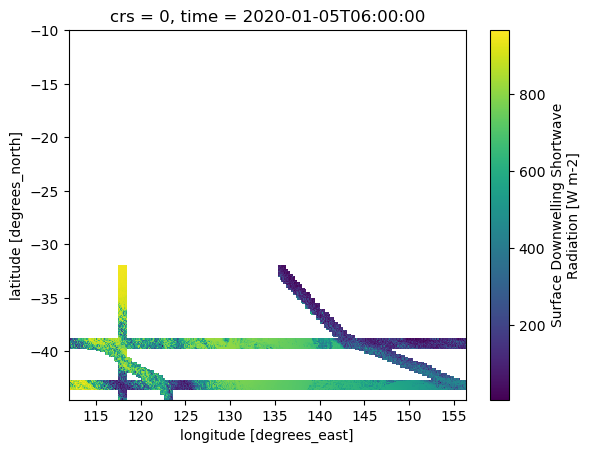

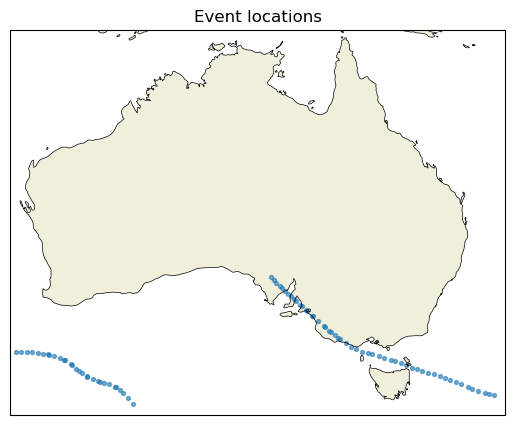

In [137]:
time = '2020-01-05T06'
date = np.datetime64(time)

ghi_masked.sel(time=time).plot()

data = ds.where((ds.date == date) & lat_max & lat_min & lon_max & lon_min, drop=True)
# data.where(ds1.line_id == 1, drop=True)

lats = data["latitude"].values
lons = data["longitude"].values 

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([112, 157, -45, -10], crs=ccrs.PlateCarree())

ax.scatter(
    lons, lats,
    s=8, alpha=0.6,
    transform=ccrs.PlateCarree()
)

ax.set_title("Event locations")
plt.show()